In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df1 = pd.read_csv("Intermodalcompany1_dataset1(in).csv")
df2 = pd.read_csv("Intermodalcompany1_dataset2(in).csv")
df3 = pd.read_csv("Intermodalcompany1_dataset3(in).csv")

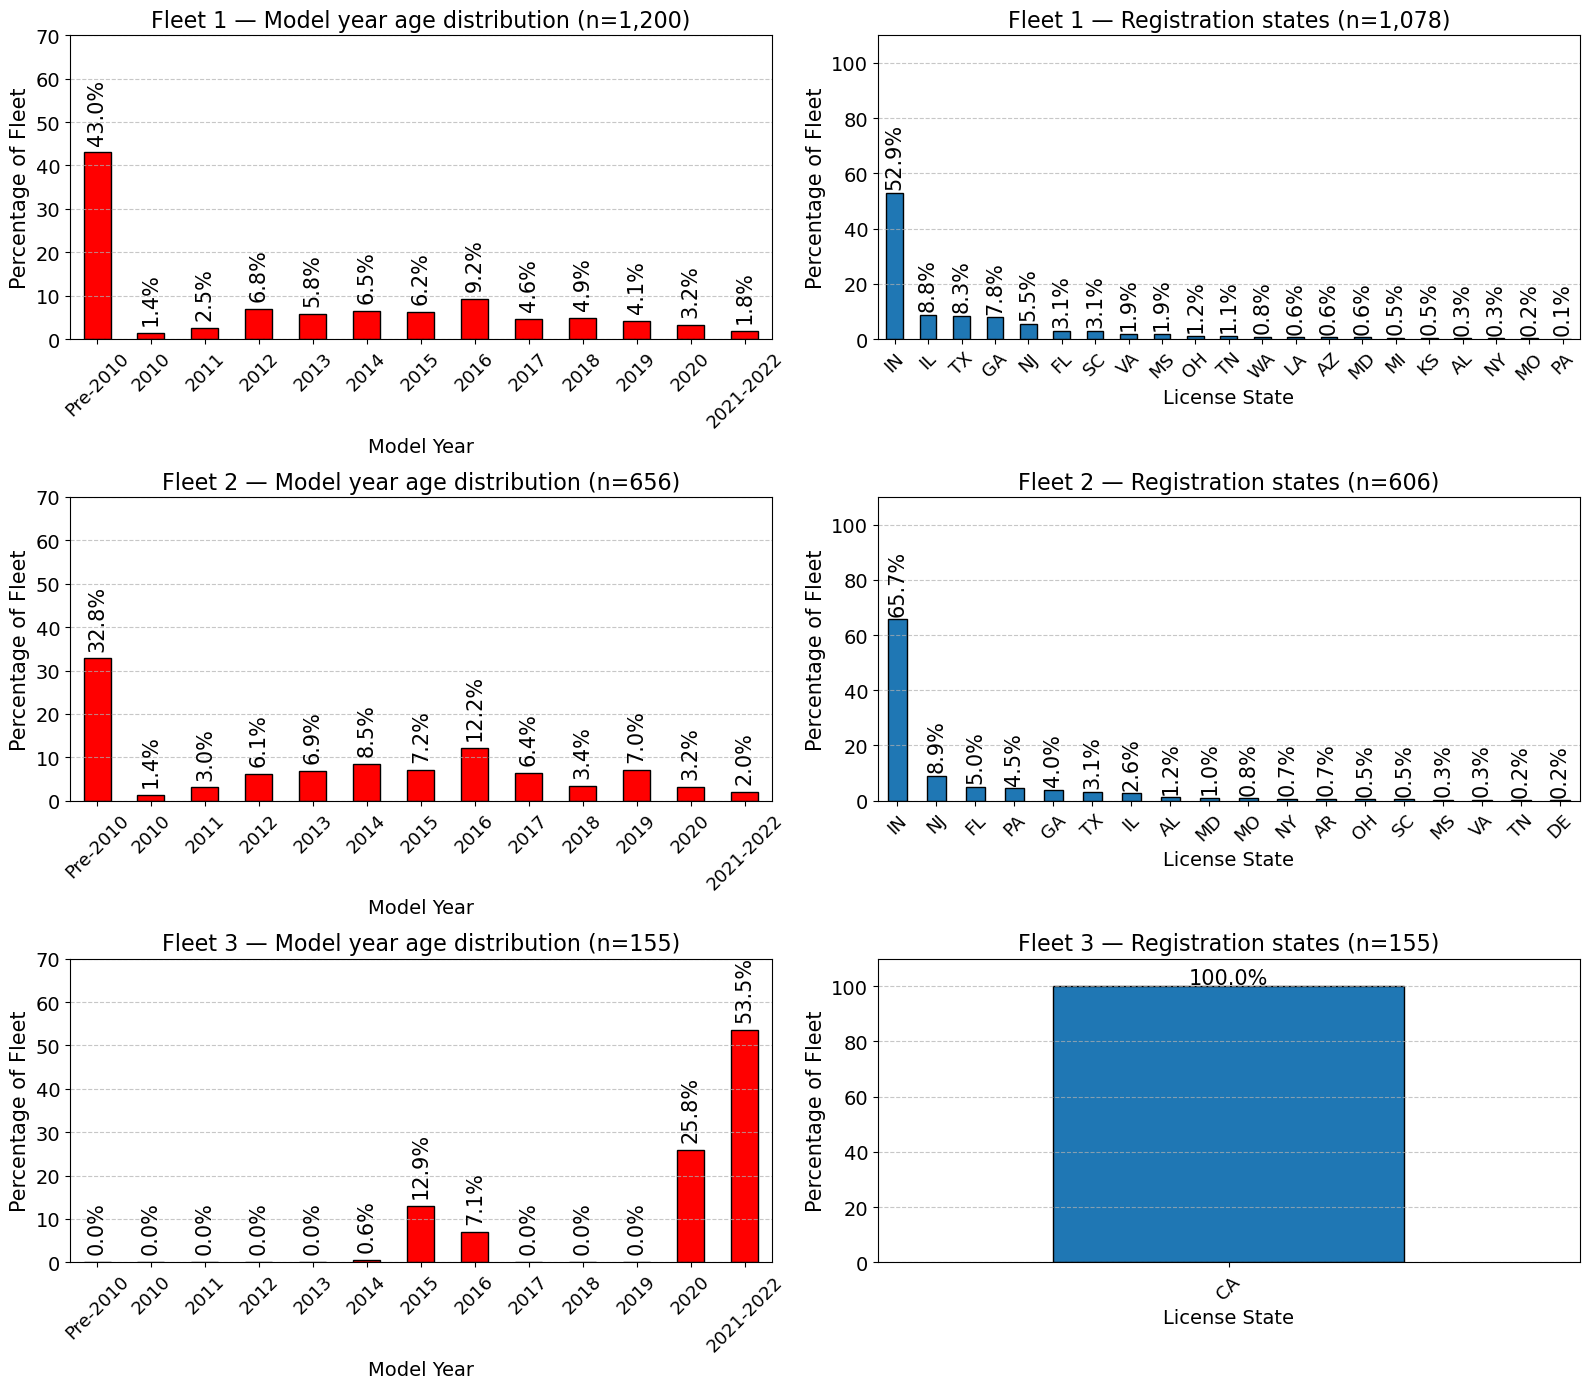

In [36]:
# If not already defined earlier:
ordered_labels = [
    "Pre-2010",
    "2010","2011","2012","2013","2014","2015","2016","2017","2018","2019","2020",
    "2021-2022"
]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
plt.subplots_adjust(hspace=0.35, wspace=0.15)
y_offset = ax.get_ylim()[1] * 0.025  # ~1.5% of axis height

# =========================
# Fleet 1
# =========================
year_series_1 = pd.to_numeric(df1["Year"], errors="coerce")
df1_year = df1.loc[year_series_1.notna()].copy()
df1_year["Year"] = year_series_1[year_series_1.notna()].astype(int)

model_group_1 = []
for y in df1_year["Year"]:
    if y < 2010:
        model_group_1.append("Pre-2010")
    elif 2010 <= y <= 2020:
        model_group_1.append(str(y))
    elif y >= 2021:
        model_group_1.append("2021-2022")
    else:
        model_group_1.append("Unknown")
df1_year["ModelYearGrouped"] = model_group_1

my_counts_1 = df1_year["ModelYearGrouped"].value_counts().reindex(ordered_labels, fill_value=0)
my_total_1 = int(my_counts_1.sum())
my_pct_1 = (my_counts_1 / my_total_1 * 100) if my_total_1 > 0 else my_counts_1.astype(float)

ax_left_1 = axes[0, 0]
my_pct_1.plot(kind="bar", ax=ax_left_1, edgecolor="black", color="red")
ax_left_1.set_xlabel("Model Year", fontsize=14)
ax_left_1.set_ylabel("Percentage of Fleet", fontsize=15)
ax_left_1.set_title(f"Fleet 1 — Model year age distribution (n={my_total_1:,})", fontsize=16)
ax_left_1.tick_params(axis="x", rotation=45)
ax_left_1.grid(axis="y", linestyle="--", alpha=0.7)
for i, v in enumerate(my_pct_1.values):
    if pd.notna(v):
        ax_left_1.text(i, v + y_offset, f"{v:.1f}%", ha="center", rotation=90, fontsize=15)

# Registration states — only rows with valid Year, clean NaNs/empties
reg_1 = df1_year["License State"].dropna()
reg_1 = reg_1.astype(str).str.strip()
reg_1 = reg_1[(reg_1 != "") & (~reg_1.str.lower().isin(["nan", "na", "none"]))]

reg_counts_1 = reg_1.value_counts()
reg_total_1  = int(reg_counts_1.sum())
reg_pct_1    = (reg_counts_1 / reg_total_1 * 100) if reg_total_1 > 0 else reg_counts_1.astype(float)
reg_pct_1    = reg_pct_1.sort_values(ascending=False)

ax_right_1 = axes[0, 1]
reg_pct_1.plot(kind="bar", ax=ax_right_1, edgecolor="black")
ax_right_1.set_xlabel("License State", fontsize=14)
ax_right_1.set_ylabel("Percentage of Fleet", fontsize=15)
ax_right_1.set_title(f"Fleet 1 — Registration states (n={reg_total_1:,})", fontsize=16)
ax_right_1.tick_params(axis="x", rotation=45)
ax_right_1.grid(axis="y", linestyle="--", alpha=0.7)
for i, v in enumerate(reg_pct_1.values):
    if pd.notna(v):
        ax_right_1.text(i,  v + y_offset, f"{v:.1f}%", ha="center", rotation=90, fontsize=15)

# =========================
# Fleet 2
# =========================
year_series_2 = pd.to_numeric(df2["Year"], errors="coerce")
df2_year = df2.loc[year_series_2.notna()].copy()
df2_year["Year"] = year_series_2[year_series_2.notna()].astype(int)

model_group_2 = []
for y in df2_year["Year"]:
    if y < 2010:
        model_group_2.append("Pre-2010")
    elif 2010 <= y <= 2020:
        model_group_2.append(str(y))
    elif y >= 2021:
        model_group_2.append("2021-2022")
    else:
        model_group_2.append("Unknown")
df2_year["ModelYearGrouped"] = model_group_2

my_counts_2 = df2_year["ModelYearGrouped"].value_counts().reindex(ordered_labels, fill_value=0)
my_total_2 = int(my_counts_2.sum())
my_pct_2 = (my_counts_2 / my_total_2 * 100) if my_total_2 > 0 else my_counts_2.astype(float)

ax_left_2 = axes[1, 0]
my_pct_2.plot(kind="bar", ax=ax_left_2, edgecolor="black", color="red")
ax_left_2.set_xlabel("Model Year", fontsize=14)
ax_left_2.set_ylabel("Percentage of Fleet", fontsize=15)
ax_left_2.set_title(f"Fleet 2 — Model year age distribution (n={my_total_2:,})", fontsize=16)
ax_left_2.tick_params(axis="x", rotation=45)
ax_left_2.grid(axis="y", linestyle="--", alpha=0.7)
for i, v in enumerate(my_pct_2.values):
    if pd.notna(v):
        ax_left_2.text(i, v + y_offset, f"{v:.1f}%", ha="center", rotation=90, fontsize=15)

# Registration states — only rows with valid Year, clean NaNs/empties
reg_2 = df2_year["License State"].dropna()
reg_2 = reg_2.astype(str).str.strip()
reg_2 = reg_2[(reg_2 != "") & (~reg_2.str.lower().isin(["nan", "na", "none"]))]

reg_counts_2 = reg_2.value_counts()
reg_total_2  = int(reg_counts_2.sum())
reg_pct_2    = (reg_counts_2 / reg_total_2 * 100) if reg_total_2 > 0 else reg_counts_2.astype(float)
reg_pct_2    = reg_pct_2.sort_values(ascending=False)

ax_right_2 = axes[1, 1]
reg_pct_2.plot(kind="bar", ax=ax_right_2, edgecolor="black")
ax_right_2.set_xlabel("License State", fontsize=14)
ax_right_2.set_ylabel("Percentage of Fleet", fontsize=15)
ax_right_2.set_title(f"Fleet 2 — Registration states (n={reg_total_2:,})", fontsize=16)
ax_right_2.tick_params(axis="x", rotation=45)
ax_right_2.grid(axis="y", linestyle="--", alpha=0.7)
for i, v in enumerate(reg_pct_2.values):
    if pd.notna(v):
        ax_right_2.text(i,  v + y_offset, f"{v:.1f}%", ha="center", rotation=90, fontsize=15)

# =========================
# Fleet 3
# =========================
year_series_3 = pd.to_numeric(df3["Year"], errors="coerce")
df3_year = df3.loc[year_series_3.notna()].copy()
df3_year["Year"] = year_series_3[year_series_3.notna()].astype(int)

model_group_3 = []
for y in df3_year["Year"]:
    if y < 2010:
        model_group_3.append("Pre-2010")
    elif 2010 <= y <= 2020:
        model_group_3.append(str(y))
    elif y >= 2021:
        model_group_3.append("2021-2022")
    else:
        model_group_3.append("Unknown")
df3_year["ModelYearGrouped"] = model_group_3

my_counts_3 = df3_year["ModelYearGrouped"].value_counts().reindex(ordered_labels, fill_value=0)
my_total_3 = int(my_counts_3.sum())
my_pct_3 = (my_counts_3 / my_total_3 * 100) if my_total_3 > 0 else my_counts_3.astype(float)

ax_left_3 = axes[2, 0]
my_pct_3.plot(kind="bar", ax=ax_left_3, edgecolor="black", color="red")
ax_left_3.set_xlabel("Model Year", fontsize=14)
ax_left_3.set_ylabel("Percentage of Fleet", fontsize=15)
ax_left_3.set_title(f"Fleet 3 — Model year age distribution (n={my_total_3:,})", fontsize=16)
ax_left_3.tick_params(axis="x", rotation=45)
ax_left_3.grid(axis="y", linestyle="--", alpha=0.7)
for i, v in enumerate(my_pct_3.values):
    if pd.notna(v):
        ax_left_3.text(i,  v + y_offset, f"{v:.1f}%", ha="center", rotation=90, fontsize=15)

# Registration states — only rows with valid Year, clean NaNs/empties
reg_3 = df3_year["License State"].dropna()
reg_3 = reg_3.astype(str).str.strip()
reg_3 = reg_3[(reg_3 != "") & (~reg_3.str.lower().isin(["nan", "na", "none"]))]

reg_counts_3 = reg_3.value_counts()
reg_total_3  = int(reg_counts_3.sum())
reg_pct_3    = (reg_counts_3 / reg_total_3 * 100) if reg_total_3 > 0 else reg_counts_3.astype(float)
reg_pct_3    = reg_pct_3.sort_values(ascending=False)

ax_right_3 = axes[2, 1]
reg_pct_3.plot(kind="bar", ax=ax_right_3, edgecolor="black")
ax_right_3.set_xlabel("License State", fontsize=14)
ax_right_3.set_ylabel("Percentage of Fleet", fontsize=15)
ax_right_3.set_title(f"Fleet 3 — Registration states (n={reg_total_3:,})", fontsize=16)
ax_right_3.tick_params(axis="x", rotation=45)
ax_right_3.grid(axis="y", linestyle="--", alpha=0.7)
for i, v in enumerate(reg_pct_3.values):
    if pd.notna(v):
        ax_right_3.text(i, v +1 , f"{v:.1f}%", ha="center", fontsize=15)

# Set y-lims by column (optional)
for r in range(3):
    axes[r, 0].set_ylim(0, 70)   # left column (model year)
    axes[r, 1].set_ylim(0, 110)  # right column (registration states)

for ax in axes.flat:
    ax.tick_params(axis="x", labelsize=13)
    ax.tick_params(axis="y", labelsize=14)
    
plt.tight_layout()
plt.show()
